# NEWSPAPER ARTICLES

In [1]:
import spacy

# Load the language model
nlp = spacy.load("en_core_web_sm")

In [2]:
#Import libraries 

import pandas as pd
from spacy.lang.en import English

# Load spaCy English model (download if not already installed)
nlp = English()

# Assuming arxiv_data.csv is in your working directory
df = pd.read_csv("cnn4.csv")

# Get the first 20 abstracts and combine them into one string
first_20_news = " ".join(df["SUMMARY"].iloc[:150])


In [3]:
#Tokenization

# Create a spaCy document from the combined abstracts
doc = nlp(first_20_news)

# Get the tokens as a list
news_tokens = [token.text.lower() for token in doc if not token.is_stop]



In [4]:
# Function to calculate TTR

# Calculate the number of unique tokens (types)
unique_tokens = len(set(news_tokens))

# Calculate TTR (ratio of unique tokens to total tokens)
ttr = unique_tokens / len(news_tokens)

print("Newspaper Articles")
print("Type-Token Ratio (TTR):", ttr)


Newspaper Articles
Type-Token Ratio (TTR): 0.3417742888494978


In [5]:
import spacy
from collections import Counter
import pandas as pd

# Step 1: Make sure spaCy and the language model are installed
# pip install spacy
# python -m spacy download en_core_web_sm

# Step 2: Load the English language model
nlp = spacy.load("en_core_web_sm")

# Step 3: Process the document text with spaCy
doc = nlp(first_20_news)

# Step 4: Count the parts of speech
pos_counts = Counter(token.pos_ for token in doc)

# Step 5: Create a DataFrame for nicer display and sort by frequency
pos_df_sorted = pd.DataFrame(pos_counts.items(), columns=["Part of Speech", "Frequency"]).sort_values(by="Frequency", ascending=False)

# Display the table
print(pos_df_sorted)

   Part of Speech  Frequency
1            NOUN       3381
9           PROPN       2361
13          PUNCT       2329
8             ADP       1889
5            VERB       1810
7             DET       1406
3             ADJ       1222
4            PRON        864
2             AUX        772
14          SPACE        557
11            ADV        538
6            PART        450
10          CCONJ        443
0             NUM        410
12          SCONJ        246
15            SYM         23
17              X          6
16           INTJ          5


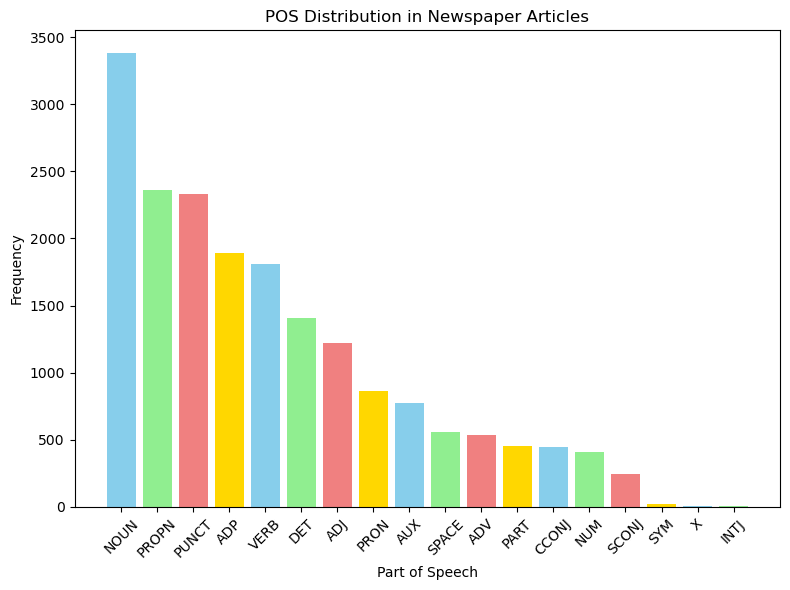

In [6]:
import matplotlib.pyplot as plt

# Get frequencies from DataFrame
pos = pos_df_sorted['Part of Speech']
frequency = pos_df_sorted['Frequency']

# Create a bar chart
plt.figure(figsize=(8, 6))  # Adjust figure size as desired
plt.bar(pos, frequency, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.xlabel('Part of Speech')
plt.ylabel('Frequency')
plt.title('POS Distribution in Newspaper Articles')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


In [7]:
# Count only the frequency of nouns, adjectives, verbs, and adverbs
pos_counts = {"NOUN": 0, "ADJ": 0, "VERB": 0, "ADV": 0}
for token in doc:
    if token.pos_ in pos_counts:
        pos_counts[token.pos_] += 1

# Convert the counts to a DataFrame for better visualization and sorting
pos_df_filtered = pd.DataFrame(list(pos_counts.items()), columns=['Part of Speech', 'Frequency'])

# Sort the DataFrame by Frequency in descending order
pos_df_filtered.sort_values(by='Frequency', ascending=False, inplace=True)

# Reset the index of the DataFrame for a clean table
pos_df_filtered.reset_index(drop=True, inplace=True)

# Display the table
print("Newspaper Articles")
print(pos_df_filtered)

Newspaper Articles
  Part of Speech  Frequency
0           NOUN       3381
1           VERB       1810
2            ADJ       1222
3            ADV        538


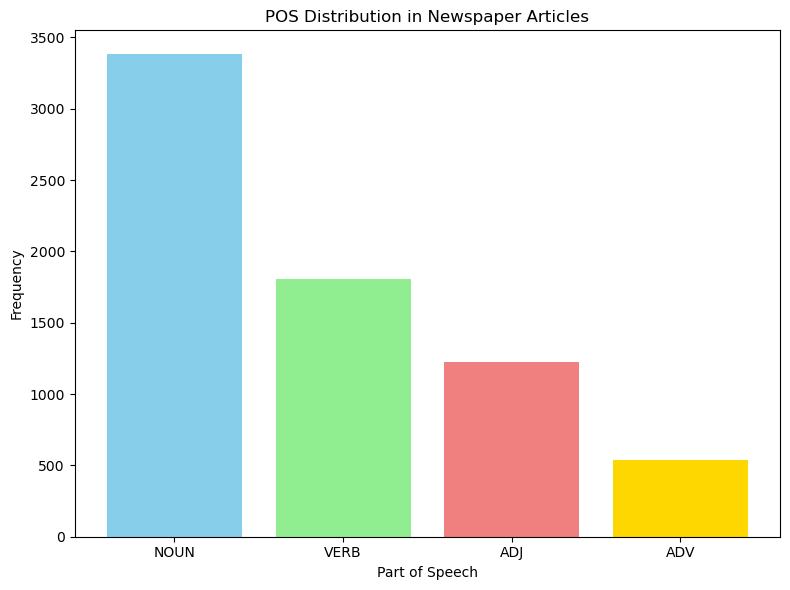

In [9]:
#Visualization

import matplotlib.pyplot as plt

# Get frequencies from DataFrame
pos = pos_df_filtered['Part of Speech']
frequency = pos_df_filtered['Frequency']

# Create a bar chart
plt.figure(figsize=(8, 6))  # Adjust figure size as desired
plt.bar(pos, frequency, color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
plt.xlabel('Part of Speech')
plt.ylabel('Frequency')
plt.title('POS Distribution in Newspaper Articles')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()
